#Clusterización con K-means


Carga de los datos


In [1]:
import pandas as pd
datos = pd.read_csv("housing.csv")

datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

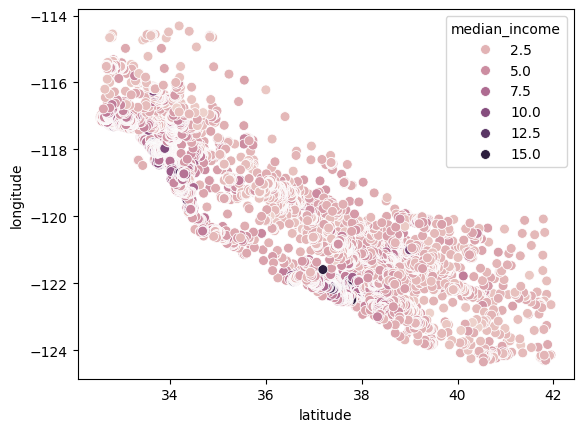

In [6]:
import seaborn as sb

sb.scatterplot(
    x="latitude",
    y="longitude",
    data=datos,
    hue="median_income",
    s=50
)

In [7]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


In [17]:
from sklearn.cluster import KMeans

X = datos.loc[:, ["latitude", "longitude", "median_income"]]

modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(X)

In [10]:
predicciones.shape

(20640,)

In [18]:
X["segmento_economico"] = predicciones

In [19]:
X

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,3
1,37.86,-122.22,8.3014,3
2,37.85,-122.24,7.2574,3
3,37.85,-122.25,5.6431,4
4,37.85,-122.25,3.8462,4
...,...,...,...,...
20635,39.48,-121.09,1.5603,0
20636,39.49,-121.21,2.5568,0
20637,39.43,-121.22,1.7000,0
20638,39.43,-121.32,1.8672,0


In [20]:
X["segmento_economico"].value_counts()

,count
segmento_economico,
2,6573
5,4628
0,4548
4,3465
1,768
3,658


<Axes: xlabel='latitude', ylabel='longitude'>

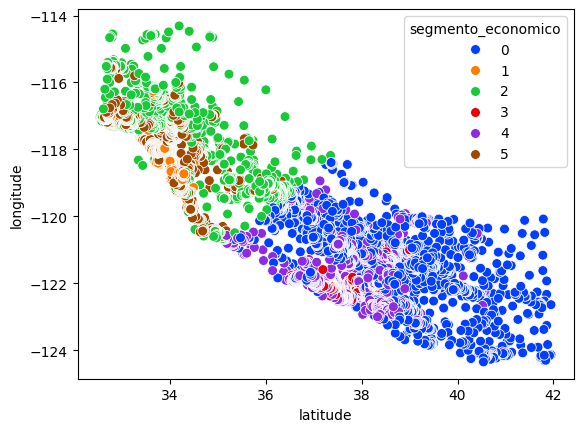

In [22]:
import seaborn as sb

sb.scatterplot(
    x="latitude",
    y="longitude",
    data=X,
    hue="segmento_economico",
    palette= "bright",
    s=50
)

<Axes: xlabel='segmento_economico', ylabel='count'>

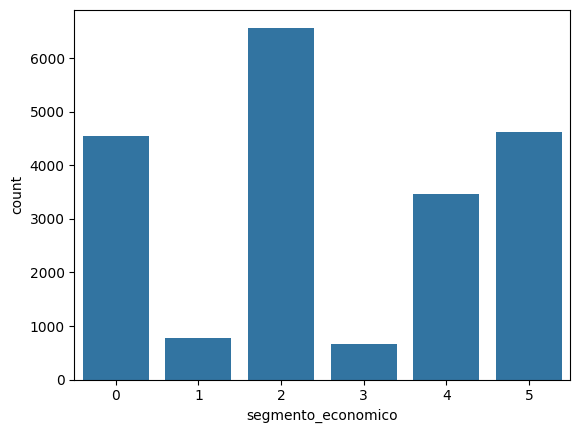

In [23]:
sb.countplot(x="segmento_economico", data=X)

In [24]:
X.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.516051
1,8.920370
2,2.631273
3,8.300929
4,4.644580
5,4.914859
